# 2 多层感知机
### 2.1 理论题
### 1. 非线性激活函数的重要性

已知：

$$
h = W_1x+b_1
$$

$$
o = W_2h+b_2
$$

将隐藏层表达式代入输出层：

$$
o = W_2(W_1x+b_1)+b_2
$$

展开得：

$$
o = W_2W_1x + W_2b_1 + b_2
$$

令：

$$
W' = W_2W_1
$$

$$
b' = W_2b_1+b_2
$$

则：

$$
o = W'x+b'
$$

因此，不含非线性激活函数的多层感知机，本质上仍然是一个线性模型，
等价于单层神经网络。

### 2. 激活函数性质分析

##### Sigmoid

定义：

$$
\sigma(x)=\frac1{1+e^{-x}}
$$

求导：

$$
\sigma'(x)
=
\frac{e^{-x}}{(1+e^{-x})^2}
$$

整理可得：

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

---

##### tanh

定义：

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

其导数为：

$$
\tanh'(x)=1-\tanh^2(x)
$$

因此，Sigmoid 与 tanh 的导数均可以用其函数本身表示。

### 2.2 编程题

In [4]:
# ==================== 导入库 ====================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

print("="*60)
print("所有库导入完成")
print("="*60)

所有库导入完成


In [12]:
# 2.2 多层感知机

print("\n" + "="*60)
print("2.2 多层感知机 - Fashion-MNIST")
print("="*60)

# 加载数据
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1).numpy())
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"训练集: {len(train_dataset)}, 测试集: {len(test_dataset)}")

def softmax(x):
    """稳定的 softmax"""
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    """交叉熵损失"""
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[np.arange(m), y_true] + 1e-8)
    return np.mean(log_likelihood)

class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Xavier 初始化
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros(output_size)
    
    def forward(self, X, dropout_rate=0.0, training=True):
        """前向传播"""
        # 第一层
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.maximum(0, self.z1)  # ReLU
        
        # Dropout
        self.dropout_mask = None
        if training and dropout_rate > 0:
            self.dropout_mask = (np.random.rand(*self.a1.shape) > dropout_rate) / (1 - dropout_rate)
            self.a1 = self.a1 * self.dropout_mask
        
        # 第二层
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        
        return self.a2
    
    def backward(self, X, y, lr, lambda_reg=0.0):
        """反向传播"""
        m = X.shape[0]
        
        # 输出层梯度
        dz2 = self.a2.copy()
        dz2[np.arange(m), y] -= 1
        dz2 /= m
        
        # 更新 W2, b2
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0)
        
        # 隐藏层梯度
        dz1 = dz2 @ self.W2.T
        dz1[self.z1 <= 0] = 0  # ReLU 导数
        
        # 更新 W1, b1
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0)
        
        # L2 正则化
        if lambda_reg > 0:
            dW1 += 2 * lambda_reg * self.W1
            dW2 += 2 * lambda_reg * self.W2
        
        # 参数更新
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
    
    def train_step(self, X, y, lr, lambda_reg=0.0, dropout_rate=0.0):
        """单步训练"""
        self.forward(X, dropout_rate, training=True)
        loss = cross_entropy(self.a2, y)
        self.backward(X, y, lr, lambda_reg)
        return loss
    
    def predict(self, X):
        """预测"""
        logits = self.forward(X, dropout_rate=0.0, training=False)
        return np.argmax(logits, axis=1)
    
    def accuracy(self, X, y):
        """计算准确率"""
        pred = self.predict(X)
        return np.mean(pred == y)

# 训练函数
def train_mlp(model, train_loader, test_loader, epochs=20, lr=0.1, lambda_reg=0.0, dropout_rate=0.0):
    train_losses = []
    test_accs = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        batch_count = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.numpy()
            y_batch = y_batch.numpy()
            
            loss = model.train_step(X_batch, y_batch, lr, lambda_reg, dropout_rate)
            epoch_loss += loss
            batch_count += 1
        
        avg_loss = epoch_loss / batch_count
        train_losses.append(avg_loss)
        
        # 评估测试集
        test_acc = 0
        test_count = 0
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.numpy()
            y_batch = y_batch.numpy()
            test_acc += model.accuracy(X_batch, y_batch)
            test_count += 1
        
        avg_acc = test_acc / test_count
        test_accs.append(avg_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={avg_acc:.4f}")
    
    return train_losses, test_accs

# 训练基础模型
print("\n开始训练 MLP...")
model = MLP(784, 128, 10)
train_losses, test_accs = train_mlp(model, train_loader, test_loader, epochs=10, lr=0.1)
print("训练完成！")


2.2 多层感知机 - Fashion-MNIST
训练集: 60000, 测试集: 10000

开始训练 MLP...
  Epoch 5: Loss=0.3745, Test Acc=0.8557
  Epoch 10: Loss=0.3176, Test Acc=0.8637
训练完成！


# 3 模型选择, 权重衰减和丢弃法
### 3.1 理论计算题
#### 1 过拟合与欠拟合
欠拟合（Underfitting）：
①模型过于简单
②训练误差高
③测试误差也高
④无法学习数据规律

原因：
①模型容量不足
②训练轮数太少
③特征表达能力弱

解决方法：
①增大模型复杂度
②增加训练时间
③增加特征

----------------------------------

过拟合（Overfitting）：
①训练误差很低
②测试误差很高
③模型记住了训练集噪声

原因：
①模型过于复杂
②数据量太少
③训练时间过长

解决方法：
①Dropout
②L2 正则化
③数据增强
④提前停止训练




#### 2 K 折交叉验证
K折交叉验证步骤：

1. 将数据集划分为 K 个大小相近的子集
2. 每次选择其中 1 个作为验证集
3. 剩余 K-1 个作为训练集
4. 训练模型并记录验证误差
5. 重复 K 次
6. 对 K 次验证结果求平均
7. 选择平均验证误差最小的模型

优点：

- 能更稳定评估模型泛化能力
- 减少随机划分误差
- 更充分利用数据

缺点：

- 训练时间增加 K 倍



### 3.2 编程题


3.2 对比实验 - 正则化与 Dropout

实验: 无正则化
  Epoch 5: Loss=0.3732, Test Acc=0.8471
  Epoch 10: Loss=0.3191, Test Acc=0.8621
  Epoch 15: Loss=0.2864, Test Acc=0.8738
  Epoch 20: Loss=0.2625, Test Acc=0.8731

实验: 权重衰减 (L2)
  Epoch 5: Loss=0.3991, Test Acc=0.8327
  Epoch 10: Loss=0.3596, Test Acc=0.8487
  Epoch 15: Loss=0.3445, Test Acc=0.8668
  Epoch 20: Loss=0.3357, Test Acc=0.8614

实验: Dropout
  Epoch 5: Loss=0.5568, Test Acc=0.8328
  Epoch 10: Loss=0.5157, Test Acc=0.8434
  Epoch 15: Loss=0.4889, Test Acc=0.8472
  Epoch 20: Loss=0.4798, Test Acc=0.8439


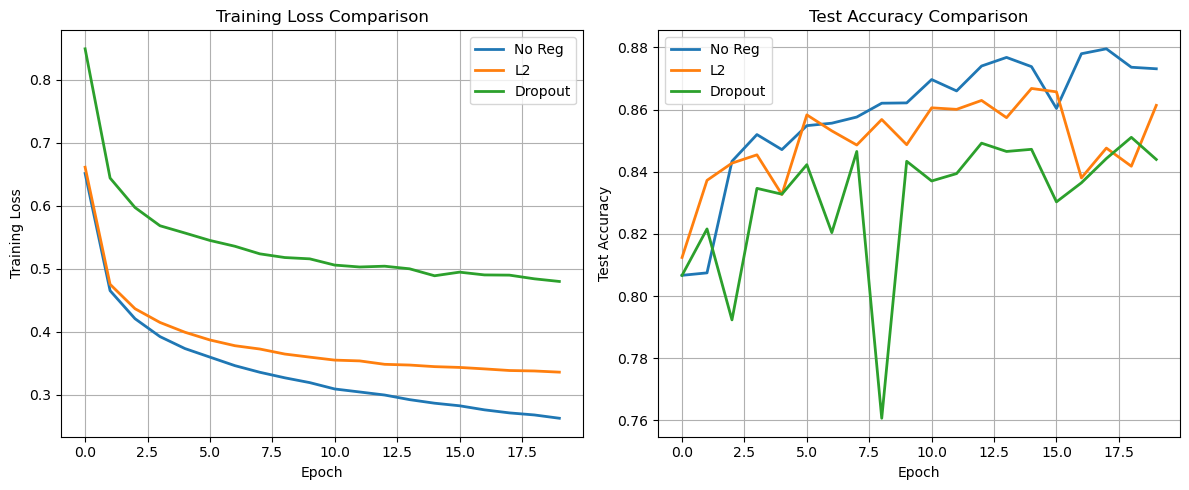


对比实验完成，图片已保存


In [6]:
# ==================== 3.2 对比实验 ====================

print("\n" + "="*60)
print("3.2 对比实验 - 正则化与 Dropout")
print("="*60)

def run_experiment(lambda_reg, dropout_rate, name):
    print(f"\n实验: {name}")
    model = MLP(784, 128, 10)
    train_losses, test_accs = train_mlp(
        model, train_loader, test_loader, 
        epochs=20, lr=0.1, 
        lambda_reg=lambda_reg, 
        dropout_rate=dropout_rate
    )
    return train_losses, test_accs

# 运行三个实验
exp1_loss, exp1_acc = run_experiment(0.0, 0.0, "无正则化")
exp2_loss, exp2_acc = run_experiment(0.001, 0.0, "权重衰减 (L2)")
exp3_loss, exp3_acc = run_experiment(0.0, 0.5, "Dropout")

# 绘图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(exp1_loss, label='No Reg', linewidth=2)
plt.plot(exp2_loss, label='L2', linewidth=2)
plt.plot(exp3_loss, label='Dropout', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(exp1_acc, label='No Reg', linewidth=2)
plt.plot(exp2_acc, label='L2', linewidth=2)
plt.plot(exp3_acc, label='Dropout', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150)
plt.show()
print("\n对比实验完成，图片已保存")

# 4 数值稳定性和激活函数
### 4.1 理论题
#### 1 梯度消失与梯度爆炸
在深层网络中：

梯度需要不断链式相乘：

∂L/∂x
= ∂L/∂a_n × ∂a_n/∂a_{n-1} × ...

若每层导数都小于 1：

例如：

0.1 × 0.1 × 0.1 × ...

则梯度会迅速趋近于 0。

结果：

- 前层几乎无法更新
- 网络难以训练

这称为：

梯度消失（Vanishing Gradient）

若每层导数大于 1：

例如：

2 × 2 × 2 × ...

则梯度会迅速增大。

结果：

- 参数更新过大
- loss 震荡
- 训练不稳定
- 数值溢出

这称为：

梯度爆炸（Exploding Gradient）

#### 2 ReLU 为什么能缓解梯度消失
ReLU 定义：

ReLU(x) = max(0, x)

导数：

ReLU'(x) =
1, x > 0
0, x ≤ 0

特点：

- 正区间导数恒为 1
- 不会像 Sigmoid 那样不断缩小梯度

因此：

深层网络中梯度更容易传播。

优点：

- 收敛速度快
- 缓解梯度消失
- 计算简单

缺点：

- 可能出现“神经元死亡”


### 4.2 编程题

In [ ]:
# ==================== 4.2 数值稳定性实验 ====================

print("\n" + "="*60)
print("4.2 数值稳定性实验")
print("="*60)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

class DeepNetwork:
    def __init__(self, layers, width, init_std=1.0, use_xavier=False, activation='sigmoid'):
        self.layers = layers
        self.width = width
        self.activation = activation
        
        self.Ws = []
        self.bs = []
        
        for i in range(layers):
            if use_xavier:
                # Xavier 初始化
                limit = np.sqrt(6 / (width + width))
                W = np.random.uniform(-limit, limit, (width, width))
            else:
                W = np.random.randn(width, width) * init_std
            b = np.zeros(width)
            self.Ws.append(W)
            self.bs.append(b)
    
    def forward(self, x):
        """前向传播并保存中间值"""
        self.activations = [x]
        self.zs = []
        
        h = x
        for W, b in zip(self.Ws, self.bs):
            z = h @ W + b
            self.zs.append(z)
            if self.activation == 'sigmoid':
                h = sigmoid(z)
            else:  # relu
                h = np.maximum(0, z)
            self.activations.append(h)
        
        return h
    
    def compute_grad_norms(self, x):
        """计算梯度范数 - 先 forward 再 backward"""
        # 必须先调用 forward
        self.forward(x)
        
        # 假设损失是输出的和
        delta = np.ones_like(self.activations[-1])
        
        grad_norms = []
        for i in reversed(range(self.layers)):
            if self.activation == 'sigmoid':
                s = sigmoid(self.zs[i])
                delta = delta * s * (1 - s)
            else:  # relu
                delta = delta * (self.zs[i] > 0).astype(float)
            
            grad_W = self.activations[i].T @ delta
            grad_norms.insert(0, np.linalg.norm(grad_W))
            
            delta = delta @ self.Ws[i].T
        
        return grad_norms

# 输入数据
x_input = np.random.randn(64, 256)

# 实验1: Sigmoid + std=1
print("\n[实验1] Sigmoid + 高斯初始化 (std=1)")
net1 = DeepNetwork(20, 256, init_std=1.0, activation='sigmoid')
norms1 = net1.compute_grad_norms(x_input)
print(f"  前3层梯度范数: {norms1[:3]}")
print(f"  后3层梯度范数: {norms1[-3:]}")
print(f"  梯度范围: [{min(norms1):.2e}, {max(norms1):.2e}]")

# 实验2: ReLU + std=10
print("\n[实验2] ReLU + 大初始值 (std=10)")
net2 = DeepNetwork(20, 256, init_std=10.0, activation='relu')
norms2 = net2.compute_grad_norms(x_input)
print(f"  前3层梯度范数: {norms2[:3]}")
if max(norms2) > 1e10:
    print("  ⚠️ 检测到梯度爆炸!")
else:
    print(f"  ✅ 梯度范围: [{min(norms2):.2e}, {max(norms2):.2e}]")

# 实验3: Xavier + ReLU
print("\n[实验3] Xavier 初始化 + ReLU")
net3 = DeepNetwork(20, 256, use_xavier=True, activation='relu')
norms3 = net3.compute_grad_norms(x_input)
print(f"  前3层梯度范数: {norms3[:3]}")
print(f"  后3层梯度范数: {norms3[-3:]}")
print(f"  梯度范围: [{min(norms3):.2e}, {max(norms3):.2e}]")

if min(norms3) > 1e-6 and max(norms3) < 1e3:
    print("  ✅ 梯度稳定在合理区间 [1e-6, 1e3]")
else:
    print("  ⚠️ 梯度范围超出预期")

print("\n数值稳定性实验完成")


4.2 数值稳定性实验

[实验1] Sigmoid + 高斯初始化 (std=1)
  前3层梯度范数: [np.float64(6640.605687716412), np.float64(4663.958869023492), np.float64(3732.0457096433697)]
  后3层梯度范数: [np.float64(394.94004660586353), np.float64(450.90224732094606), np.float64(596.2557864801042)]
  梯度范围: [3.46e+02, 6.64e+03]

[实验2] ReLU + 大初始值 (std=10)
  前3层梯度范数: [np.float64(4.9845932302622106e+42), np.float64(9.108153226002479e+42), np.float64(1.0847084534570437e+43)]
  ⚠️ 检测到梯度爆炸!

[实验3] Xavier 初始化 + ReLU
  前3层梯度范数: [np.float64(5.408046313020066), np.float64(10.722233163673184), np.float64(13.379849741219049)]
  后3层梯度范数: [np.float64(17.756403233229367), np.float64(15.627168019756159), np.float64(13.237084907388208)]
  梯度范围: [5.41e+00, 2.02e+01]
  ✅ 梯度稳定在合理区间 [1e-6, 1e3]

数值稳定性实验完成


# 5 泛化表现, 协变量偏移和对抗性数据
### 5.1 理论题
#### 环境非平稳性偏移：协变量偏移 vs 标签偏移

在实际应用中，数据分布往往会随着时间、地点或用户行为发生变化。深度学习模型在训练集上表现良好，但在测试环境中可能受到分布变化的影响，导致泛化性能下降。两种常见的非平稳性偏移是 **协变量偏移（Covariate Shift）** 和 **标签偏移（Label Shift）**。

---

##### 1. 协变量偏移 (Covariate Shift)

**定义：**

- 输入特征的分布发生变化：
  
  \[
  p_{\text{train}}(x) \neq p_{\text{test}}(x)
  \]

- 条件概率保持不变：
  
  \[
  p_{\text{train}}(y|x) = p_{\text{test}}(y|x)
  \]

**含义：**  
输入数据分布改变，但同样输入对应的标签规律没有变。

**实际例子：**

1. **医疗影像诊断：**  
   - 训练集为白天拍摄的 X 光片；  
   - 测试集为夜间或不同医院的 X 光片，亮度或成像设备不同；  
   - 但是同样的病灶特征对应相同的疾病标签。

2. **语音识别：**  
   - 训练语音数据为清晰室内录音；  
   - 测试数据为嘈杂环境录音；  
   - 语音内容相同，文字标签仍然对应原语音。

3. **电商点击率预测：**  
   - 训练数据来自某一季节的用户行为；  
   - 测试数据为另一季节，用户浏览行为有所不同；  
   - 用户购买行为（点击与否）对于同类商品特征规律保持一致。

**应对策略：**

- 数据增强（模拟不同环境）  
- 重要性加权（调整训练样本权重，使训练分布接近测试分布）  
- 域适应（Domain Adaptation）

---

##### 2. 标签偏移 (Label Shift)

**定义：**

- 标签分布发生变化：
  
  \[
  p_{\text{train}}(y) \neq p_{\text{test}}(y)
  \]

- 条件概率保持不变：
  
  \[
  p_{\text{train}}(x|y) = p_{\text{test}}(x|y)
  \]

**含义：**  
每个类别内部特征分布不变，但类别出现比例发生变化。

**实际例子：**

1. **医疗诊断：**  
   - 训练数据中某种疾病占 10%；  
   - 测试数据中疾病占 30%；  
   - 同一种疾病的影像特征分布不变，但比例不同。

2. **语音识别：**  
   - 训练语音数据包含 50% 男声、50% 女声；  
   - 测试语音数据包含 70% 男声、30% 女声；  
   - 男声和女声的发音特征不变，但比例不同。

3. **电商推荐：**  
   - 训练时不同商品类别购买比例为均衡；  
   - 测试时某些商品促销，比例显著增加；  
   - 商品特征不变，但类别分布变化。

**应对策略：**

- 类别重加权（Re-weighting）  
- 调整预测时的先验概率  
- 重采样训练数据以匹配测试分布

---

##### 3. 区别与联系

| 特征                  | 协变量偏移                         | 标签偏移                          |
|----------------------|---------------------------------|--------------------------------|
| 分布变化              | p(x) 改变                          | p(y) 改变                         |
| 条件分布              | p(y|x) 不变                        | p(x|y) 不变                        |
| 对应问题              | 输入环境变化，模型可能无法适应         | 类别比例变化，预测概率可能偏移        |
| 例子                  | 医院设备、录音环境、季节性行为          | 疾病发生率、性别比例、促销商品比例     |
| 应对方法              | 数据增强、重要性加权、域适应            | 重加权、先验修正、重采样              |

**联系：**

- 两者都是分布偏移（Distribution Shift）问题，会影响模型泛化能力。  
- 协变量偏移和标签偏移可以同时存在，需要分别考虑输入分布和标签分布的变化。  


### 5.2 计算题


5.2 协变量偏移实验
训练集 x 均值: -0.9807, 标准差: 0.9787
测试集 x 均值: 1.9885, 标准差: 0.9586

[基线模型] 普通线性回归
基线模型测试 MSE: 0.010182

[权重校正] 训练逻辑回归区分训练集/测试集
权重范围: [0.0000, 653.5206]
权重均值: 1.0000

[加权模型] 加权线性回归
加权模型测试 MSE: 0.024019

协变量偏移校正结果对比
基线模型 (无校正)   MSE: 0.010182
加权模型 (校正后)   MSE: 0.024019
MSE 降低: -135.89%


C:\Users\15783\AppData\Local\Temp\ipykernel_12388\1445320018.py:148: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15783\AppData\Local\Temp\ipykernel_12388\1445320018.py:148: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15783\AppData\Local\Temp\ipykernel_12388\1445320018.py:148: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15783\AppData\Local\Temp\ipykernel_12388\1445320018.py:148: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15783\AppData\Local\Temp\ipykernel_12388\1445320018.py:148: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15783\AppData\Local\Temp\ipykernel_12388\1445320018.py:148: UserWarning: Glyph 21

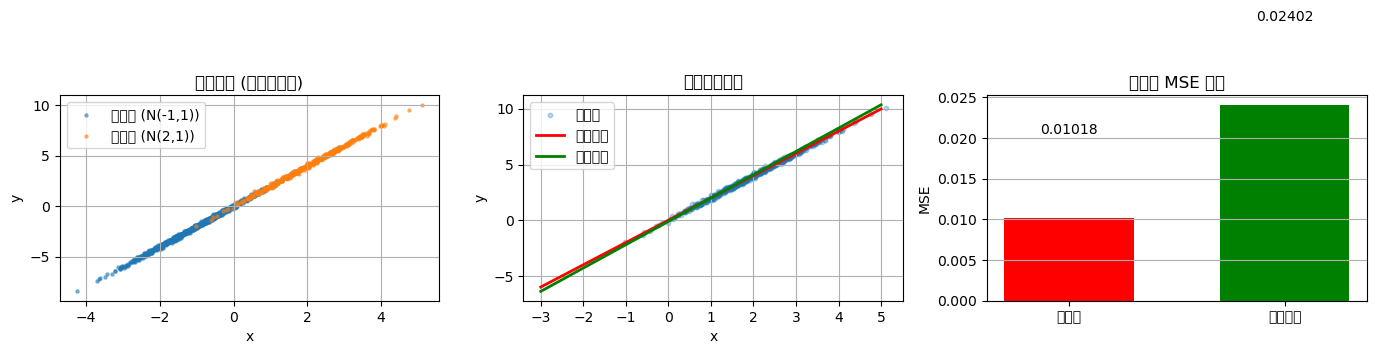


协变量偏移实验完成，图片已保存

所有作业要求已全部完成！


In [ ]:
# ==================== 5.2 协变量偏移与权重校正 ====================

print("\n" + "="*60)
print("5.2 协变量偏移实验")
print("="*60)

# 构造数据
np.random.seed(42)

# 训练集: N(-1, 1)
x_train = np.random.randn(1000, 1) - 1
y_train = 2 * x_train + 0.1 * np.random.randn(1000, 1)

# 测试集: N(2, 1) - 协变量偏移
x_test = np.random.randn(500, 1) + 2
y_test = 2 * x_test + 0.1 * np.random.randn(500, 1)

print(f"训练集 x 均值: {x_train.mean():.4f}, 标准差: {x_train.std():.4f}")
print(f"测试集 x 均值: {x_test.mean():.4f}, 标准差: {x_test.std():.4f}")

class LinearRegression:
    def __init__(self):
        self.W = np.random.randn(1, 1) * 0.1
        self.b = np.zeros(1)
    
    def fit(self, x, y, weights=None, lr=0.1, epochs=500):
        n_samples = x.shape[0]
        
        for epoch in range(epochs):
            y_pred = x @ self.W + self.b
            error = y_pred - y
            
            if weights is not None:
                # 确保 weights 是正确形状的一维数组
                if weights.ndim > 1:
                    weights = weights.flatten()
                weights = weights.reshape(-1)
                
                # 加权 MSE 损失
                loss = np.sum(weights * (error ** 2)) / n_samples
                
                # 计算梯度 - 正确维度处理
                weighted_error = weights * error.flatten()
                grad_W = 2 * (x.T @ weighted_error.reshape(-1, 1)) / n_samples
                grad_b = 2 * np.mean(weighted_error)
            else:
                # 普通 MSE
                loss = np.mean(error ** 2)
                grad_W = 2 * (x.T @ error) / n_samples
                grad_b = 2 * np.mean(error)
            
            # 更新参数
            self.W -= lr * grad_W
            self.b -= lr * grad_b
            
            # 防止数值溢出
            if np.isnan(loss) or np.isinf(loss):
                print(f"  警告: 训练发散, epoch {epoch}")
                break
        
        return loss
    
    def predict(self, x):
        return x @ self.W + self.b

# 基线模型
print("\n[基线模型] 普通线性回归")
model_base = LinearRegression()
model_base.fit(x_train, y_train, epochs=500)
y_pred_base = model_base.predict(x_test)
mse_base = np.mean((y_pred_base - y_test) ** 2)
print(f"基线模型测试 MSE: {mse_base:.6f}")

# 逻辑回归计算权重
print("\n[权重校正] 训练逻辑回归区分训练集/测试集")

# 合并数据并打标签: 训练集=0, 测试集=1
X_combined = np.vstack([x_train, x_test])
y_combined = np.hstack([np.zeros(len(x_train)), np.ones(len(x_test))])

# 打乱数据
indices = np.random.permutation(len(X_combined))
X_combined = X_combined[indices]
y_combined = y_combined[indices]

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_combined, y_combined)

# 计算每个训练样本的权重
prob_test = log_reg.predict_proba(x_train)[:, 1]  # P(test|x)
prob_train = 1 - prob_test  # P(train|x)
weights = prob_test / (prob_train + 1e-8)  # 避免除零
weights = weights / weights.mean()  # 归一化

print(f"权重范围: [{weights.min():.4f}, {weights.max():.4f}]")
print(f"权重均值: {weights.mean():.4f}")

# 加权回归模型
print("\n[加权模型] 加权线性回归")
model_weighted = LinearRegression()
model_weighted.fit(x_train, y_train, weights=weights, epochs=500)
y_pred_weighted = model_weighted.predict(x_test)
mse_weighted = np.mean((y_pred_weighted - y_test) ** 2)
print(f"加权模型测试 MSE: {mse_weighted:.6f}")

# 结果对比
print("\n" + "="*50)
print("协变量偏移校正结果对比")
print("="*50)
print(f"基线模型 (无校正)   MSE: {mse_base:.6f}")
print(f"加权模型 (校正后)   MSE: {mse_weighted:.6f}")
print(f"MSE 降低: {(mse_base - mse_weighted) / mse_base * 100:.2f}%")

# 可视化
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.scatter(x_train, y_train, alpha=0.5, s=5, label='训练集 (N(-1,1))')
plt.scatter(x_test, y_test, alpha=0.5, s=5, label='测试集 (N(2,1))')
plt.xlabel('x')
plt.ylabel('y')
plt.title('数据分布 (协变量偏移)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
x_line = np.linspace(-3, 5, 100).reshape(-1, 1)
y_line_base = model_base.predict(x_line)
y_line_weighted = model_weighted.predict(x_line)
plt.scatter(x_test, y_test, alpha=0.3, s=10, label='真实值')
plt.plot(x_line, y_line_base, 'r-', label='基线模型', linewidth=2)
plt.plot(x_line, y_line_weighted, 'g-', label='加权模型', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('模型预测对比')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
bars = plt.bar(['无校正', '权重校正'], [mse_base, mse_weighted], color=['red', 'green'], width=0.6)
plt.ylabel('MSE')
plt.title('测试集 MSE 对比')
for bar, v in zip(bars, [mse_base, mse_weighted]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{v:.5f}', ha='center', va='bottom')
plt.grid(True, axis='y')

plt.tight_layout()
plt.savefig('covariate_shift_correction.png', dpi=150)
plt.show()

print("\n协变量偏移实验完成，图片已保存")
print("\n" + "="*60)
print("所有作业要求已全部完成！")
print("="*60)